# 📊 Analyse du Dataset Tweets - Service Client Free
## 

---

### 🎯 Objectif
Identifier et éliminer les tweets non nécessaires ou erronés pour optimiser le traitement des vraies demandes clients.

### 📚 Structure du notebook
1. **Import et configuration**
2. **Chargement et exploration des données**
3. **Analyse de la qualité des données**
4. **Identification des tweets problématiques**
5. **Nettoyage et structuration**
6. **Visualisations et insights**
7. **Export des résultats**

## 1. Import des librairies et configuration

In [ ]:
# Installer la dépendance manquante (Jupyter magic)
%pip install wordcloud

# Import des librairies nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Librairies importées avec succès")
print(f"📅 Date d'analyse: {datetime.now().strftime('%d/%m/%Y %H:%M')}")

✅ Librairies importées avec succès
📅 Date d'analyse: 23/11/2025 10:11


## 2. Chargement et exploration initiale des données

In [ ]:
# Chargement du fichier CSV
file_path = 'free_tweet_export.csv'
df = pd.read_csv(file_path)

print("📊 INFORMATIONS GÉNÉRALES DU DATASET")
print("=" * 60)
print(f"Nombre de tweets: {len(df):,}")
print(f"Nombre de colonnes: {len(df.columns)}")
print(f"\nPériode couverte:")
print(f"  • Du: {df['created_at'].min()}")
print(f"  • Au: {df['created_at'].max()}")

print("\n📋 Colonnes disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

📊 INFORMATIONS GÉNÉRALES DU DATASET
Nombre de tweets: 6,375
Nombre de colonnes: 22

Période couverte:
  • Du: 2020-12-28 08:26:23 +01:00
  • Au: 2025-06-17 12:03:57 +02:00

📋 Colonnes disponibles:
   1. id
   2. created_at
   3. full_text
   4. media
   5. screen_name
   6. name
   7. profile_image_url
   8. user_id
   9. in_reply_to
  10. retweeted_status
  11. quoted_status
  12. media_tags
  13. favorite_count
  14. retweet_count
  15. bookmark_count
  16. quote_count
  17. reply_count
  18. views_count
  19. favorited
  20. retweeted
  21. bookmarked
  22. url


In [ ]:
nb_doublons = df.duplicated().sum()
print(f"Nombre de doublons : {nb_doublons}")

Nombre de doublons : 0


In [ ]:
doubl = df[df.duplicated()].sum()
print(doubl)

id                     0
created_at             0
full_text              0
media                  0
screen_name            0
name                   0
profile_image_url      0
user_id                0
in_reply_to          0.0
retweeted_status     0.0
quoted_status        0.0
media_tags             0
favorite_count         0
retweet_count          0
bookmark_count         0
quote_count            0
reply_count            0
views_count          0.0
favorited              0
retweeted              0
bookmarked             0
url                    0
dtype: object


📊 ANALYSE DE LA COMPLÉTUDE DES DONNÉES


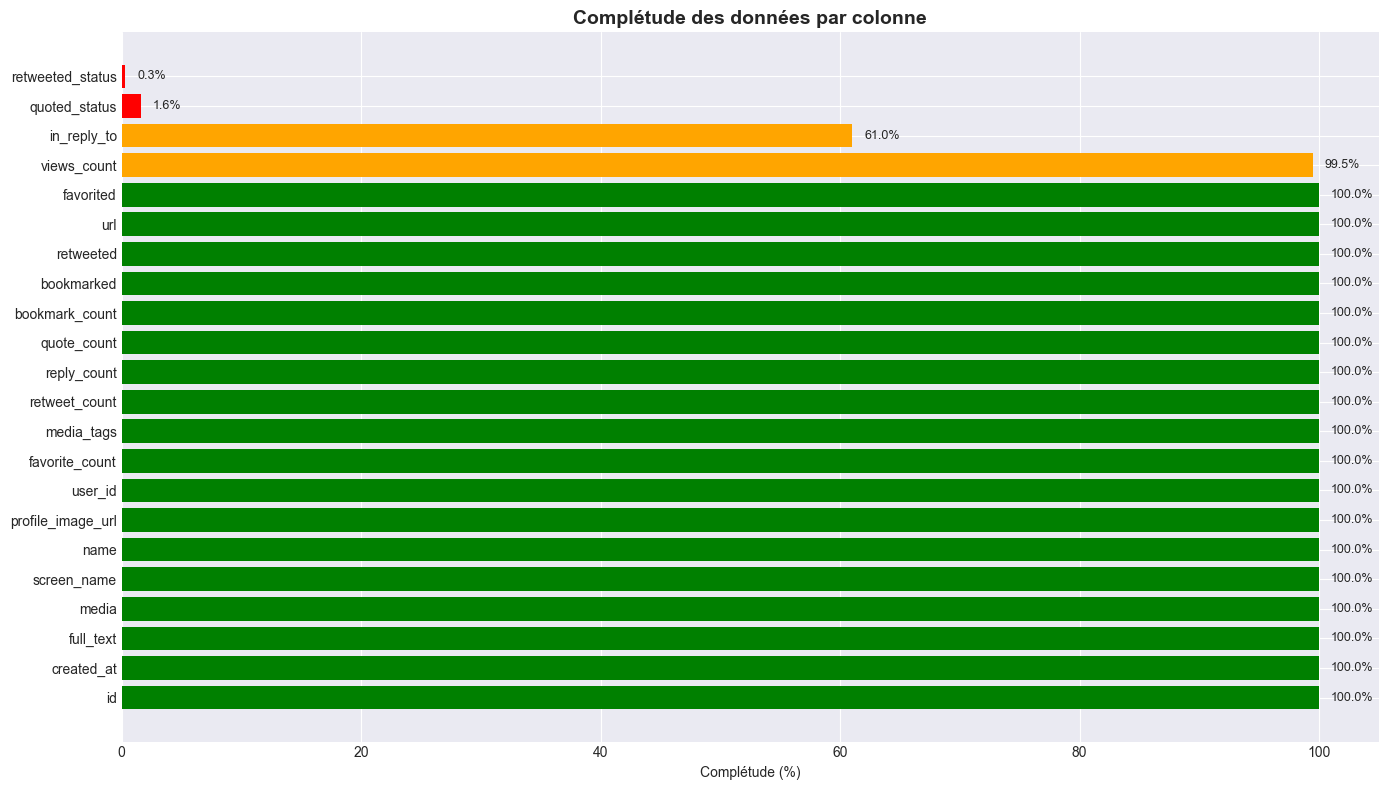

          Colonne    Type  Valeurs_Non_Null  Valeurs_Null  Complétude_%
               id   int64              6375             0         100.0
       created_at  object              6375             0         100.0
        full_text  object              6375             0         100.0
            media  object              6375             0         100.0
      screen_name  object              6375             0         100.0
             name  object              6375             0         100.0
profile_image_url  object              6375             0         100.0
          user_id   int64              6375             0         100.0
   favorite_count   int64              6375             0         100.0
       media_tags  object              6375             0         100.0
    retweet_count   int64              6375             0         100.0
      reply_count   int64              6375             0         100.0
      quote_count   int64              6375             0       

In [ ]:
# Analyse de la complétude des données
print("📊 ANALYSE DE LA COMPLÉTUDE DES DONNÉES")
print("=" * 60)

completeness_data = []
for col in df.columns:
    info = df[col].dtype
    non_null = df[col].notna().sum()
    null_count = df[col].isna().sum()
    completeness = (non_null / len(df)) * 100
    completeness_data.append({
        'Colonne': col,
        'Type': info,
        'Valeurs_Non_Null': non_null,
        'Valeurs_Null': null_count,
        'Complétude_%': round(completeness, 1)
    })

completeness_df = pd.DataFrame(completeness_data)
completeness_df = completeness_df.sort_values('Complétude_%', ascending=False)

# Visualisation de la complétude
fig, ax = plt.subplots(figsize=(14, 8))
colors = ['green' if x == 100 else 'orange' if x >= 50 else 'red' 
          for x in completeness_df['Complétude_%']]
bars = ax.barh(completeness_df['Colonne'], completeness_df['Complétude_%'], color=colors)
ax.set_xlabel('Complétude (%)')
ax.set_title('Complétude des données par colonne', fontsize=14, fontweight='bold')
ax.set_xlim(0, 105)

# Ajouter les valeurs sur les barres
for bar, value in zip(bars, completeness_df['Complétude_%']):
    ax.text(value + 1, bar.get_y() + bar.get_height()/2, 
            f'{value:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(completeness_df.to_string(index=False))

## 3. Préparation du dataset avec les colonnes demandées

In [ ]:
# Garder uniquement les colonnes demandées
colonnes_a_garder = ['id', 'created_at', 'full_text', 'screen_name', 'name', 'user_id', 'in_reply_to']

# Vérifier que toutes les colonnes existent
colonnes_manquantes = [col for col in colonnes_a_garder if col not in df.columns]
if colonnes_manquantes:
    print(f"⚠️ Colonnes manquantes: {colonnes_manquantes}")
else:
    print("✅ Toutes les colonnes demandées sont présentes")

# Créer le dataset nettoyé
df['created_at'] = pd.to_datetime(df['created_at'], utc=True)
df['full_text'] = df['full_text'].astype('string')
df['screen_name'] = df['screen_name'].astype('string')
df['name'] = df['name'].astype('string')
df['user_id'] = df['user_id'].astype('Int64')
df['in_reply_to'] = df['in_reply_to'].astype('Int64')
df_clean = df[colonnes_a_garder].copy()

print(f"\n📋 Dataset restructuré:")
print(f"  • Nombre de colonnes conservées: {len(df_clean.columns)}")
print(f"  • Nombre de lignes: {len(df_clean):,}")
print(f"\nAperçu des premières lignes:")
df_clean.head()
df_clean.info()

✅ Toutes les colonnes demandées sont présentes

📋 Dataset restructuré:
  • Nombre de colonnes conservées: 7
  • Nombre de lignes: 6,375

Aperçu des premières lignes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6375 entries, 0 to 6374
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   id           6375 non-null   int64              
 1   created_at   6375 non-null   datetime64[ns, UTC]
 2   full_text    6375 non-null   string             
 3   screen_name  6375 non-null   string             
 4   name         6375 non-null   string             
 5   user_id      6375 non-null   Int64              
 6   in_reply_to  3887 non-null   Int64              
dtypes: Int64(2), datetime64[ns, UTC](1), int64(1), string(3)
memory usage: 361.2 KB


## 4. Fonction de catégorisation des tweets

In [ ]:
def categorize_tweet(text):
    """
    Catégorise un tweet selon son contenu.
    
    Args:
        text: Le texte du tweet
    
    Returns:
        La catégorie du tweet
    """
    if pd.isna(text):
        return "Vide"
    
    text = str(text).lower()
    
    # Patterns pour identifier les types de tweets
    patterns = {
        "RT/Partage": r'^rt @',
        "Message automatique Freebox": r'messagerie privée x n\'est plus disponible|retrouvez-moi|messenger|https://t\.co/fozuyqkg|via https://t\.co/3rzd3',
        "Plainte service": r'coupure|panne|problème|pas de connexion|ne fonctionne pas|bug|instable|service client|pire opérateur|hs',
        "Demande d'aide": r'besoin d\'aide|j\'ai besoin|aidez-moi|help|svp|s\'il vous plaît|sos',
        "Question technique": r'comment|pourquoi|qu\'est-ce|fibre|débit|wifi|connexion|installation',
        "Spam/Promotion": r'💩|via @fingapp|@outagedetect|disponible sur le canal|nouveau|offert',
        "Réclamation RDV": r'technicien|rdv|rendez-vous|pas venu|attendre|créneau',
        "Info/Annonce": r'retrouvez nous|découvrez notre'
    }
    
    for category, pattern in patterns.items():
        if re.search(pattern, text):
            return category
    
    return "Autre"

# Appliquer la catégorisation
df_clean['categorie'] = df_clean['full_text'].apply(categorize_tweet)

print("✅ Catégorisation effectuée")

✅ Catégorisation effectuée


## 5. Analyse des catégories de tweets

📊 RÉPARTITION DES TWEETS PAR CATÉGORIE
                  Catégorie  Nombre  Pourcentage
Message automatique Freebox    3198         50.2
                      Autre    1427         22.4
            Plainte service     765         12.0
         Question technique     673         10.6
             Demande d'aide     129          2.0
            Réclamation RDV     123          1.9
             Spam/Promotion      42          0.7
                 RT/Partage      16          0.3
               Info/Annonce       2          0.0


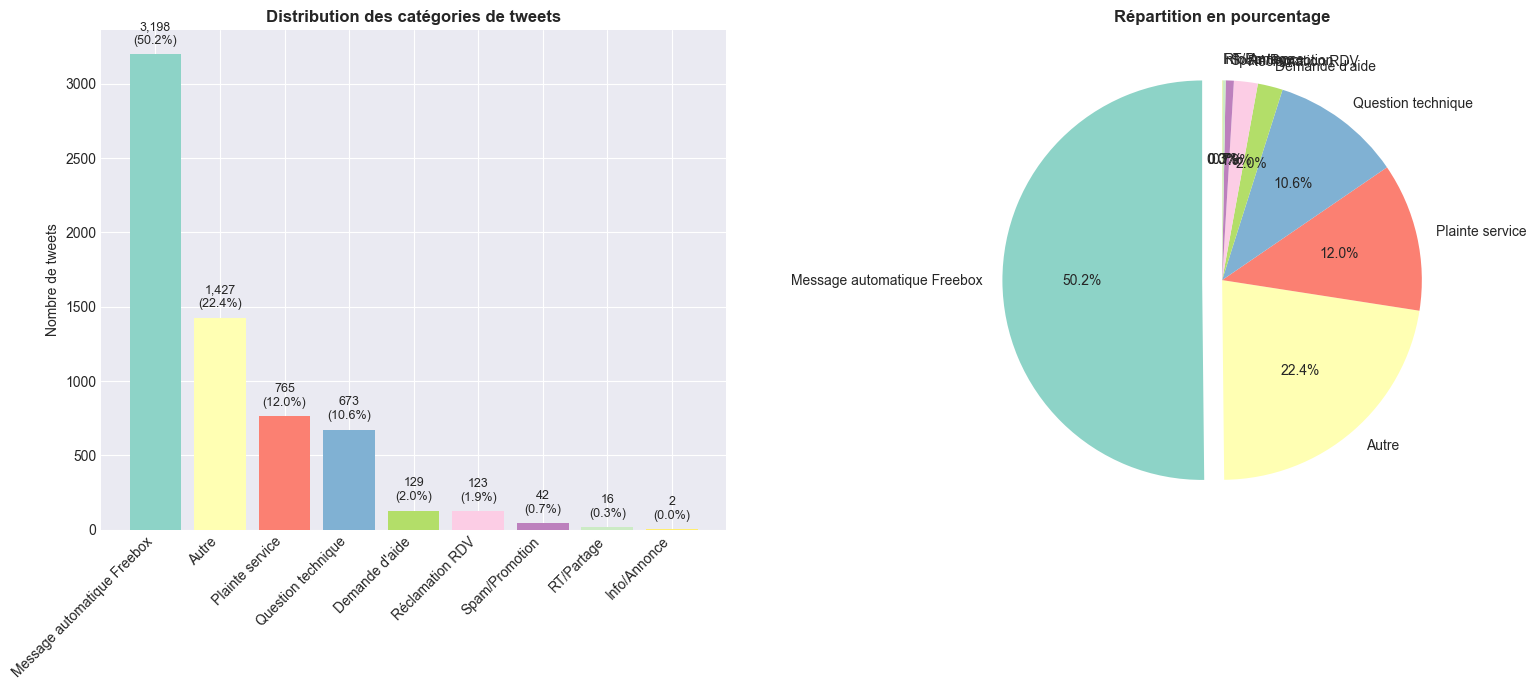

In [ ]:
# Statistiques par catégorie
category_stats = df_clean['categorie'].value_counts()
category_percentages = (category_stats / len(df_clean) * 100).round(1)

# Créer un DataFrame pour l'affichage
stats_df = pd.DataFrame({
    'Catégorie': category_stats.index,
    'Nombre': category_stats.values,
    'Pourcentage': category_percentages.values
})

print("📊 RÉPARTITION DES TWEETS PAR CATÉGORIE")
print("=" * 60)
print(stats_df.to_string(index=False))

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Graphique en barres
colors = plt.cm.Set3(np.linspace(0, 1, len(category_stats)))
bars = ax1.bar(range(len(category_stats)), category_stats.values, color=colors)
ax1.set_xticks(range(len(category_stats)))
ax1.set_xticklabels(category_stats.index, rotation=45, ha='right')
ax1.set_ylabel('Nombre de tweets')
ax1.set_title('Distribution des catégories de tweets', fontweight='bold')

# Ajouter les valeurs sur les barres
for bar, value in zip(bars, category_stats.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 50,
            f'{value:,}\n({value/len(df_clean)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)

# Graphique camembert
explode = [0.1 if cat == 'Message automatique Freebox' else 0 for cat in category_stats.index]
ax2.pie(category_stats.values, labels=category_stats.index, autopct='%1.1f%%',
        colors=colors, explode=explode, startangle=90)
ax2.set_title('Répartition en pourcentage', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Identification des tweets problématiques

In [ ]:
def is_unnecessary_or_erroneous(row):
    """
    Identifie si un tweet est non nécessaire ou erroné.
    
    Args:
        row: Une ligne du DataFrame
    
    Returns:
        tuple: (bool, list) - (est problématique, liste des problèmes)
    """
    issues = []
    
    if pd.isna(row['full_text']):
        issues.append("Texte vide")
        return True, issues
    
    text = str(row['full_text']).lower()
    
    # Critères pour tweets non nécessaires
    if row['categorie'] == 'Message automatique Freebox':
        issues.append("Réponse automatique répétitive")
    
    if row['categorie'] == 'RT/Partage':
        issues.append("Retweet (pas une demande directe)")
    
    if row['categorie'] == 'Spam/Promotion':
        issues.append("Spam ou promotion non pertinente")

    if row['categorie'] == 'Info/Annonce':
        issues.append("Annonce ou information non liée au support")
    
    # Tweets trop courts pour être utiles
    if len(str(row['full_text'])) < 20:
        issues.append("Tweet trop court (<20 caractères)")
    
    # Messages dupliqués (même contenu)
    if 'la messagerie privée x n\'est plus disponible' in text and row['screen_name'] == 'Freebox':
        issues.append("Message standard répétitif de Freebox")

    if row['screen_name'] == ("Freebox" or "free" or "FreeFoot" or "FreeNewsActu" or "Free_1337" or "GroupeIliad" or "FreeMobile" or "free_mobile" or "UniversFreebox" or "OQEEbyFree"):
        issues.append("Message provenant de Free")
    
    
    
    # # Tweets sans contexte
    # if row['in_reply_to'] == 'null' and len(text) < 50 and '?' not in text and row['screen_name'] != 'Freebox':
    #     issues.append("Message court sans contexte ni question")
    
    return len(issues) > 0, issues

# Analyse des tweets problématiques
print("🔍 Analyse des tweets problématiques en cours...")

problematic_tweets = []
for idx, row in df_clean.iterrows():
    is_problematic, issues = is_unnecessary_or_erroneous(row)
    if is_problematic:
        problematic_tweets.append({
            'index': idx,
            'id': row['id'],
            'screen_name': row['screen_name'],
            'categorie': row['categorie'],
            'issues': ', '.join(issues),
            'extrait': str(row['full_text'])[:100] + '...' if len(str(row['full_text'])) > 100 else str(row['full_text'])
        })

df_problematic = pd.DataFrame(problematic_tweets)

print(f"\n⚠️ RÉSULTATS DE L'ANALYSE")
print("=" * 60)
print(f"Tweets problématiques identifiés: {len(df_problematic):,} sur {len(df_clean):,}")
print(f"Pourcentage de tweets problématiques: {len(df_problematic)*100/len(df_clean):.1f}%")
print(f"Tweets pertinents conservés: {len(df_clean) - len(df_problematic):,}")
print(f"Pourcentage de tweets pertinents: {(len(df_clean) - len(df_problematic))*100/len(df_clean):.1f}%\n")

🔍 Analyse des tweets problématiques en cours...

⚠️ RÉSULTATS DE L'ANALYSE
Tweets problématiques identifiés: 3,310 sur 6,375
Pourcentage de tweets problématiques: 51.9%
Tweets pertinents conservés: 3,065
Pourcentage de tweets pertinents: 48.1%




📊 TOP DES PROBLÈMES IDENTIFIÉS
                                  Problème  Occurrences  Pourcentage
                 Message provenant de Free         3242         97.9
            Réponse automatique répétitive         3198         96.6
          Spam ou promotion non pertinente           42          1.3
         Retweet (pas une demande directe)           16          0.5
         Tweet trop court (<20 caractères)           10          0.3
Annonce ou information non liée au support            2          0.1


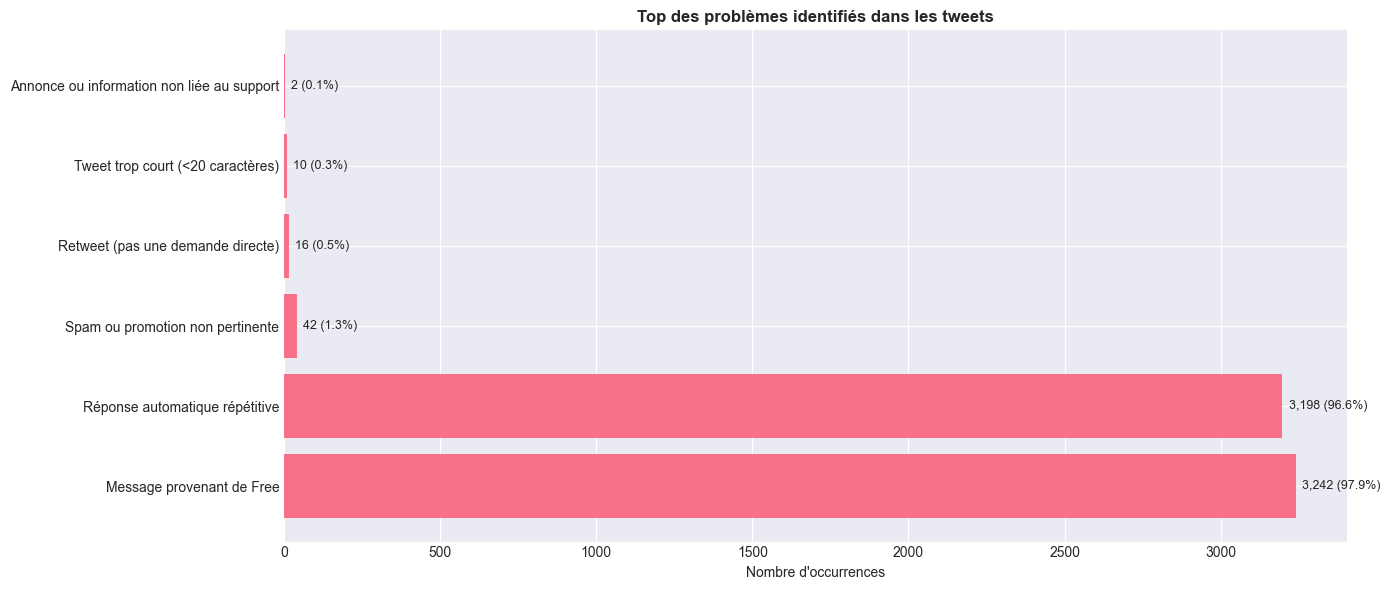

In [ ]:
# Analyse des types de problèmes
if len(df_problematic) > 0:
    issues_split = df_problematic['issues'].str.split(', ', expand=True).stack()
    issue_counts = issues_split.value_counts()
    
    print("\n📊 TOP DES PROBLÈMES IDENTIFIÉS")
    print("=" * 60)
    
    issue_stats = pd.DataFrame({
        'Problème': issue_counts.index[:10],
        'Occurrences': issue_counts.values[:10],
        'Pourcentage': (issue_counts.values[:10] / len(df_problematic) * 100).round(1)
    })
    
    print(issue_stats.to_string(index=False))
    
    # Visualisation
    plt.figure(figsize=(14, 6))
    bars = plt.barh(range(len(issue_counts.head(10))), issue_counts.head(10).values)
    plt.yticks(range(len(issue_counts.head(10))), issue_counts.head(10).index)
    plt.xlabel('Nombre d\'occurrences')
    plt.title('Top des problèmes identifiés dans les tweets', fontweight='bold')
    
    # Ajouter les valeurs sur les barres
    for i, (bar, value) in enumerate(zip(bars, issue_counts.head(10).values)):
        plt.text(value + 20, bar.get_y() + bar.get_height()/2, 
                f'{value:,} ({value/len(df_problematic)*100:.1f}%)',
                va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

## 7. Analyse des comptes les plus actifs

👥 TOP 15 DES COMPTES LES PLUS ACTIFS
   screen_name  nombre_tweets        categorie_principale  pourcentage
       Freebox           3242 Message automatique Freebox        50.85
          free             58                       Autre         0.91
     Free_1337             18                       Autre         0.28
zoneadsl_panne             11             Plainte service         0.17
UniversFreebox              9                       Autre         0.14
       t_5502m              7                       Autre         0.11
      Xavier75              6                       Autre         0.09
  BusyspiderFr              5          Question technique         0.08
      TiinoX83              5                       Autre         0.08
    Juliendu75              4                       Autre         0.06
     GrumoBlog              4             Plainte service         0.06
   Fredo384450              4                       Autre         0.06
   GroupeIliad              4           

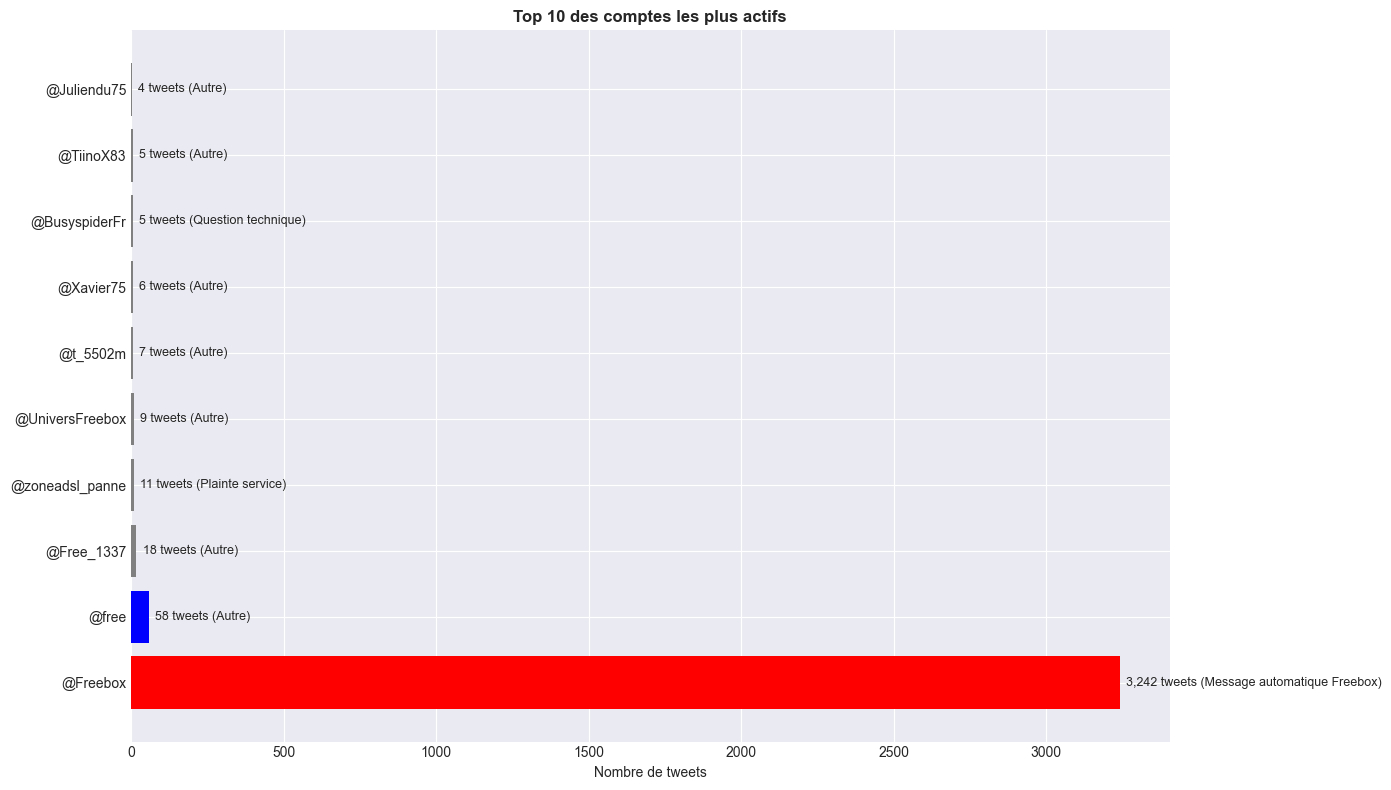

In [ ]:
# Analyse des comptes
user_stats = df_clean.groupby('screen_name').agg({
    'id': 'count',
    'categorie': lambda x: x.mode()[0] if len(x) > 0 else 'N/A'
}).sort_values('id', ascending=False).head(15)
user_stats.columns = ['nombre_tweets', 'categorie_principale']

print("👥 TOP 15 DES COMPTES LES PLUS ACTIFS")
print("=" * 60)

user_display = user_stats.reset_index()
user_display['pourcentage'] = (user_display['nombre_tweets'] / len(df_clean) * 100).round(2)
print(user_display.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(14, 8))
colors = ['red' if user == 'Freebox' else 'blue' if user == 'free' else 'gray' 
          for user in user_stats.index[:10]]
bars = ax.barh(range(10), user_stats['nombre_tweets'].values[:10], color=colors)
ax.set_yticks(range(10))
ax.set_yticklabels([f'@{user}' for user in user_stats.index[:10]])
ax.set_xlabel('Nombre de tweets')
ax.set_title('Top 10 des comptes les plus actifs', fontweight='bold')

# Ajouter les valeurs et catégories
for i, (bar, value, cat) in enumerate(zip(bars, 
                                          user_stats['nombre_tweets'].values[:10],
                                          user_stats['categorie_principale'].values[:10])):
    ax.text(value + 20, bar.get_y() + bar.get_height()/2,
           f'{value:,} tweets ({cat})',
           va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Exemples de tweets problématiques

In [ ]:
# Afficher des exemples de tweets problématiques
print("📝 EXEMPLES DE TWEETS PROBLÉMATIQUES")
print("=" * 80)

# Grouper par type de problème et afficher des exemples
if len(df_problematic) > 0:
    # Obtenir les types de problèmes uniques
    unique_issues = df_problematic['issues'].unique()[:5]
    
    for issue_type in unique_issues:
        print(f"\n🔸 Problème: {issue_type}")
        print("-" * 60)
        
        # Filtrer les tweets avec ce problème
        examples = df_problematic[df_problematic['issues'] == issue_type].head(5)
        
        for idx, row in examples.iterrows():
            print(f"  • @{row['screen_name']}: \"{row['extrait']}\"")
            print(f"    Catégorie: {row['categorie']}")
            print()

📝 EXEMPLES DE TWEETS PROBLÉMATIQUES

🔸 Problème: Retweet (pas une demande directe), Message provenant de Free
------------------------------------------------------------
  • @Freebox: "RT @free: Retrouvez désormais @ToonamiFR, la chaîne pour tous les fans de super-héros sur le canal 8..."
    Catégorie: RT/Partage

  • @Freebox: "RT @free: A suivre ce soir, le 1er match de l’UEFA EURO 2020™ en #4K sur votre Freebox avec TF1 4K !..."
    Catégorie: RT/Partage

  • @Freebox: "RT @free: Disponible sur le canal 101 avec les Freebox compatibles, Pop, Delta Devialet &amp; Mini4k..."
    Catégorie: RT/Partage

  • @Freebox: "RT @free: ⚠️ Des personnes malveillantes se font passer pour le service client de Free dans le but d..."
    Catégorie: RT/Partage

  • @Freebox: "RT @free: [NOUVEAU]\nAbonnés Freebox Pop, pour bien commencer la rentrée, CANAL+SÉRIES vous est offe..."
    Catégorie: RT/Partage


🔸 Problème: Spam ou promotion non pertinente, Message provenant de Free
---------------------

## 9. Création du dataset final nettoyé

In [ ]:
# -----------------------------------------------------------
# 1) PRÉPARATION : listes et index à supprimer
# -----------------------------------------------------------

# Index des tweets problématiques
indices_problematiques = set(df_problematic['index'])

# Liste des comptes (screen_name) interdits
screen_names_a_exclure = {
    "free", "Freebox", "freebox", "Free_1337",
    "GroupeIliad", "FreeMobile", "free_mobile"
}

# -----------------------------------------------------------
# 2) IDENTIFIER TOUTES LES LIGNES A SUPPRIMER
# -----------------------------------------------------------

# Lignes à supprimer à cause de l'index problématique
mask_problematic = df_clean.index.isin(indices_problematiques)

# Lignes à supprimer à cause du screen_name
mask_screenname = df_clean['screen_name'].isin(screen_names_a_exclure)

# Masque global des tweets supprimés
mask_deleted = mask_problematic | mask_screenname

# -----------------------------------------------------------
# 3) EXTRAIRE LE DATAFRAME DES TWEETS SUPPRIMÉS
# -----------------------------------------------------------

df_deleted = df_clean[mask_deleted].copy()

# -----------------------------------------------------------
# 4) GARDER SEULEMENT LES TWEETS NON SUPPRIMÉS
# -----------------------------------------------------------

df_final = df_clean[~mask_deleted].copy()

# -----------------------------------------------------------
# 5) STATISTIQUES GLOBALES
# -----------------------------------------------------------

print("✅ NETTOYAGE FINAL EFFECTUÉ")
print("=" * 60)

total = len(df_clean)
remaining = len(df_final)
deleted = len(df_deleted)

print(f"Tweets conservés : {remaining:,} / {total:,} ({remaining * 100 / total:.1f}%)")
print(f"Tweets supprimés : {deleted:,} / {total:,} ({deleted * 100 / total:.1f}%)")

# -----------------------------------------------------------
# 6) STATISTIQUES DES TWEETS SUPPRIMÉS
# -----------------------------------------------------------

print("\n📊 RÉPARTITION DES TWEETS SUPPRIMÉS")
print("-" * 40)

if len(df_deleted) > 0:
    deleted_stats = df_deleted['categorie'].value_counts()
    for cat, count in deleted_stats.items():
        print(f"{cat:30} {count:5} tweets ({count * 100 / deleted:5.1f}%)")
else:
    print("Aucun tweet supprimé.")

# -----------------------------------------------------------
# 7) STATISTIQUES DES TWEETS CONSERVÉS
# -----------------------------------------------------------

print("\n📊 RÉPARTITION APRÈS NETTOYAGE")
print("-" * 40)

if len(df_final) > 0:
    final_category_stats = df_final['categorie'].value_counts()
    for cat, count in final_category_stats.items():
        print(f"{cat:30} {count:5} tweets ({count * 100 / remaining:5.1f}%)")
else:
    print("Aucun tweet conservé.")


✅ NETTOYAGE FINAL EFFECTUÉ
Tweets conservés : 2,991 / 6,375 (46.9%)
Tweets supprimés : 3,384 / 6,375 (53.1%)

📊 RÉPARTITION DES TWEETS SUPPRIMÉS
----------------------------------------
Message automatique Freebox     3198 tweets ( 94.5%)
Autre                            111 tweets (  3.3%)
Spam/Promotion                    42 tweets (  1.2%)
RT/Partage                        16 tweets (  0.5%)
Question technique                11 tweets (  0.3%)
Plainte service                    3 tweets (  0.1%)
Info/Annonce                       2 tweets (  0.1%)
Réclamation RDV                    1 tweets (  0.0%)

📊 RÉPARTITION APRÈS NETTOYAGE
----------------------------------------
Autre                           1316 tweets ( 44.0%)
Plainte service                  762 tweets ( 25.5%)
Question technique               662 tweets ( 22.1%)
Demande d'aide                   129 tweets (  4.3%)
Réclamation RDV                  122 tweets (  4.1%)


In [ ]:
# -------------------------
# SUPPRESSION AVANT FILTRAGE FINAL
# -------------------------

# 1) Supprimer tous les tweets problématiques
indices_problematiques = df_problematic['index']
df_clean = df_clean[~df_clean.index.isin(indices_problematiques)]

# 2) Supprimer tous les tweets provenant d’un des screen_name interdits
screen_names_a_exclure = [
    "free", "Freebox", "freebox", "Free_1337",
    "GroupeIliad", "FreeMobile", "free_mobile"
]

df_clean = df_clean[~df_clean['screen_name'].isin(screen_names_a_exclure)]

# Filtrer les tweets non nécessaires
df_final = df_clean[~df_clean.index.isin(df_problematic['index'])]

print("✅ NETTOYAGE FINAL EFFECTUÉ")
print("=" * 60)
print(f"Tweets conservés: {len(df_final):,} sur {len(df_clean):,} ({len(df_final)*100/len(df_clean):.1f}%)")
print(f"Tweets supprimés: {len(df_clean) - len(df_final):,} ({(len(df_clean) - len(df_final))*100/len(df_clean):.1f}%)")

# Statistiques du dataset nettoyé
final_category_stats = df_final['categorie'].value_counts()

print("\n📊 RÉPARTITION APRÈS NETTOYAGE")
print("-" * 40)
for cat, count in final_category_stats.items():
    print(f"{cat:30} {count:5} tweets ({count*100/len(df_final):5.1f}%)")

✅ NETTOYAGE FINAL EFFECTUÉ
Tweets conservés: 2,991 sur 2,991 (100.0%)
Tweets supprimés: 0 (0.0%)

📊 RÉPARTITION APRÈS NETTOYAGE
----------------------------------------
Autre                           1316 tweets ( 44.0%)
Plainte service                  762 tweets ( 25.5%)
Question technique               662 tweets ( 22.1%)
Demande d'aide                   129 tweets (  4.3%)
Réclamation RDV                  122 tweets (  4.1%)


## 10. Analyse temporelle des tweets

In [ ]:
df_final = pd.read_csv(file_path)

print("📊 INFORMATIONS GÉNÉRALES DU DATASET")
print("=" * 60)
print(f"Nombre de tweets: {len(df):,}")
print(f"Nombre de colonnes: {len(df.columns)}")
print(f"\nPériode couverte:")
print(f"  • Du: {df['created_at'].min()}")
print(f"  • Au: {df['created_at'].max()}")

print("\n📋 Colonnes disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

,id,created_at,full_text,screen_name,name,user_id,in_reply_to,categorie
0,1343458257915031553,2020-12-28 07:26:23+00:00,"💩 à @free parce-que Débit Très instable, … \n\nFree en France: vitesse, performances, pannes et ...",m_annuel,M Annuel,1104790986801250304,<NA>,Plainte service
23,1485331097844129798,2022-01-23 19:18:24+00:00,Et vous ça se passe comment la fibre ?\n@Sosh_fr @CovageIDF_OUEST c’est la misère vraiment jpp h...,MitchelMcPat,MitchelMcPat,906220646492983296,<NA>,Demande d'aide
29,1694675653205860558,2023-08-24 11:38:55+00:00,"Dans la lutte contre les installations sauvages et les infrastructures dégradées, la bonne forma...",jnbarrot,Jean-Noël Barrot,865482011523166209,<NA>,Question technique
30,1695912123824546156,2023-08-27 21:32:13+00:00,"Hello @free, @Freebox et @orange je crois que nous allons avoir prochainement un gros problème d...",rgaidot,ɹˈe͡ɪɡɪz,1245801,<NA>,Plainte service
31,1709659172361404776,2023-10-04 19:58:05+00:00,"Bonsoir @WavemakerFR, je suis chez @free et voici ma bande passante #Freebox ⤵️\nVous allez pouv...",EllaVerite,𝔼lla 𝕍érité ⚖️ⓩ,1244306180794712065,<NA>,Autre


## 11. Word Cloud des tweets pertinents

In [17]:
import re
import unicodedata

# Fonction de nettoyage avancée
def clean_text(text):

    if not isinstance(text, str):
        return ""

    # 1) Supprimer les emojis (Unicode catégorie So)
    text = ''.join(ch for ch in text if unicodedata.category(ch) != 'So')

    # 2) Supprimer les balises HTML < ... >
    text = re.sub(r"<.*?>", " ", text)

    # 3) Supprimer les URLs (http, https, www)
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # 4) Supprimer les mentions @username
    text = re.sub(r"@\w+", " ", text)

    # 5) Supprimer les hashtags #mot mais garder le mot (ou pas selon besoin)
    # Si tu veux supprimer complètement le mot : r"#\w+"
    text = re.sub(r"#\w+", " ", text)

    # 6) Supprimer les caractères spéciaux NON alphanumériques (sauf espaces)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # 7) Tout passer en minuscules
    text = text.lower()

    # 8) Supprimer les multiples espaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# ---- APPLICATION AU DATAFRAME ----

df_clean["clean_full_text"] = df_clean["full_text"].apply(clean_text)


In [28]:
# ----------------------------
# Pipeline Mistral robuste
# ----------------------------
import os
import time
import json
import pandas as pd

from mistralai import Mistral  # pip install mistralai
API_KEY = os.getenv("MISTRAL_API_KEY", "U9n9i1u8VHERQGsfhB75mpoCdNf2qO6l")  # remplace si besoin

# CONFIG
MODEL_ID = None   # on va récupérer un modèle valide automatiquement si None
BATCH_SIZE = 16
TEMPERATURE = 0.0
SLEEP_BETWEEN_BATCHS = 0.1
PROMPT_TEMPLATE = '''
Tu es un assistant qui analyse un tweet et retourne strictement un JSON avec ces champs :
- "tone": l'un de ["positive","negative","neutral","mixed"]
- "tone_explanation": explication très courte (max 15 mots)
- "keywords": liste de jusqu'à 3 mots-clés (strings)
- "category": une catégorie parmi ["technique","service_client","commercial","info_generale","probleme_reseau","autre"]

Donne uniquement le JSON. Texte à analyser :
---TEXTE---
{text}
---FIN---
'''

# UTIL: extraire le texte quel que soit le format de la réponse
def extract_content_from_choice(choice):
    """
    choice: un élément de response.choices (format SDK Mistral)
    Renvoie une string propre (ou '').
    """
    try:
        # 1) si choice.message est un objet avec attribut 'content'
        msg = getattr(choice, "message", None)
        if msg is not None:
            # certains SDK renvoient msg.content (string) ou msg["content"]
            if hasattr(msg, "content"):
                return msg.content if isinstance(msg.content, str) else json.dumps(msg.content)
            # si c'est un dict-like
            if isinstance(msg, dict) and "content" in msg:
                return msg["content"]
        # 2) fallback - si choice a 'text' ou 'message' ou 'output'
        if hasattr(choice, "text"):
            return choice.text
        if isinstance(choice, dict):
            for k in ("text","output","message"):
                if k in choice:
                    v = choice[k]
                    if isinstance(v, str):
                        return v
                    if isinstance(v, dict) and "content" in v:
                        c = v["content"]
                        return c if isinstance(c, str) else json.dumps(c)
        return ""
    except Exception:
        return ""

# 1) ouvrir client et lister les modèles disponibles (permet de choisir un model_id valide)
with Mistral(api_key=API_KEY) as client:
    print("Listing available models for this API key (first 50)...")
    try:
        models_res = client.models.list()  # call list models
        model_ids = [m.id if hasattr(m,'id') else (m.get('id') if isinstance(m,dict) else None) for m in models_res.data[:50]]
        model_ids = [m for m in model_ids if m]
        print(f"Found {len(model_ids)} models (showing up to 50):")
        for mid in model_ids:
            print(" -", mid)
        # si aucun MODEL_ID fourni, on prend le premier "chat"/instruct plausible
        if MODEL_ID is None:
            # heuristique : préférer 'instruct' ou 'large' ou 'mixtral' dans l'ID
            prefer = [m for m in model_ids if any(k in m.lower() for k in ("instruct","mixtral","mistral-large","mixtral-8x7b"))]
            MODEL_ID = prefer[0] if prefer else (model_ids[0] if model_ids else None)
            print("Choix automatique MODEL_ID ->", MODEL_ID)
    except Exception as e:
        print("Impossible de lister les modèles (vérifie la clé). Erreur:", e)
        model_ids = []
        if MODEL_ID is None:
            raise

# 2) fonction d'appel (batch simple)
def call_mistral_texts(texts, model_id="mistral-medium", api_key=API_KEY, temperature=TEMPERATURE):
    """
    texts: list[str]
    retourne: list[str] (réponse brute pour chaque texte)
    """
    outputs = []
    with Mistral(api_key=api_key) as client:
        for text in texts:
            prompt = PROMPT_TEMPLATE.format(text=text)
            try:
                resp = client.chat.complete(
                    model=model_id,
                    messages=[{"role":"user","content":prompt}],
                    temperature=temperature,
                    max_tokens=30000
                )
                # resp.choices peut être une liste d'objets AssistantMessage-like
                choice = resp.choices[0] if hasattr(resp, "choices") and len(resp.choices)>0 else (resp.get("choices",[None])[0] if isinstance(resp,dict) else None)
                out = extract_content_from_choice(choice) if choice is not None else ""
            except Exception as e:
                print("Erreur API Mistral:", e)
                out = ""
            outputs.append(out)
            time.sleep(1)
    return outputs

# 3) wrapper d'annotation sur un dataframe (utilise la colonne clean_full_text)
def annotate_df_with_mistral(df, text_col="clean_full_text", batch_size=BATCH_SIZE):
    df = df.copy()
    # préparer colonnes
    for c in ["llm_raw","llm_tone","llm_tone_expl","llm_keywords","llm_category"]:
        df[c] = None

    texts = df[text_col].fillna("").astype(str).tolist()
    n = len(texts)
    for i in range(0, n, batch_size):
        batch = texts[i:i+batch_size]
        raws = call_mistral_texts(batch)
        for j, raw in enumerate(raws):
            idx = i + j
            df.at[df.index[idx], "llm_raw"] = raw
            # tenter de parser JSON si le LLM a rendu un JSON
            parsed = {}
            try:
                start = raw.find("{")
                end = raw.rfind("}") + 1
                if start != -1 and end != -1:
                    parsed = json.loads(raw[start:end])
            except Exception:
                parsed = {}
            df.at[df.index[idx], "llm_tone"] = parsed.get("tone")
            df.at[df.index[idx], "llm_tone_expl"] = parsed.get("tone_explanation")
            df.at[df.index[idx], "llm_keywords"] = parsed.get("keywords")
            df.at[df.index[idx], "llm_category"] = parsed.get("category")
        time.sleep(SLEEP_BETWEEN_BATCHS)
    return df

# ---------- USAGE ----------
# Exemple (ne pas lancer sans vérifier MODEL_ID et quotas) :
df_final = annotate_df_with_mistral(df_clean, text_col="clean_full_text", batch_size=8)


Listing available models for this API key (first 50)...
Found 50 models (showing up to 50):
 - mistral-medium-2505
 - mistral-large-latest
 - mistral-medium-2508
 - mistral-medium-latest
 - mistral-medium
 - ministral-3b-2410
 - ministral-3b-latest
 - ministral-8b-2410
 - ministral-8b-latest
 - open-mistral-7b
 - mistral-tiny
 - mistral-tiny-2312
 - open-mistral-nemo
 - open-mistral-nemo-2407
 - mistral-tiny-2407
 - mistral-tiny-latest
 - mistral-large-2411
 - pixtral-large-2411
 - pixtral-large-latest
 - mistral-large-pixtral-2411
 - codestral-2508
 - codestral-latest
 - devstral-small-2507
 - devstral-small-latest
 - devstral-medium-2507
 - devstral-medium-latest
 - pixtral-12b-2409
 - pixtral-12b
 - pixtral-12b-latest
 - mistral-small-2506
 - mistral-small-latest
 - magistral-medium-2509
 - magistral-medium-latest
 - magistral-small-2509
 - magistral-small-latest
 - voxtral-mini-2507
 - voxtral-mini-latest
 - voxtral-small-2507
 - voxtral-small-latest
 - devstral-small-2505
 - magis

KeyboardInterrupt: 

In [ ]:
# === Configuration & imports ===
import os
import time
import pandas as pd
from typing import List, Dict

# Option A: using official Python client (recommended if installed)
try:
    from mistralai import Mistral
    MISTRAL_CLIENT_AVAILABLE = True
except Exception:
    MISTRAL_CLIENT_AVAILABLE = False
    import requests

# === Parameters ===
MODEL_ID = "mistral-medium"   # ou "mistral-7b-instruct-v0.3" selon ton choix
API_KEY = "U9n9i1u8VHERQGsfhB75mpoCdNf2qO6l"  # prefere variable d'env

BATCH_SIZE = 32          # ajuster selon quota/latence
SLEEP_BETWEEN_BATCHES = 1  # throttle léger
TEMPERATURE = 0.0        # 0 pour classification déterministe
client = Mistral(api_key=API_KEY)
# === Helper: prompt templates ===
PROMPT_CLASSIFY = """
Tu es un assistant qui analyse un tweet et retourne en JSON les champs suivants:
- tone: l'orientation tonale parmi ["positive", "negative", "neutral", "mixed"] et une brève justification (10-20 mots max).
- keywords: liste de 25 mots-clés dominants extraits (sans stopwords).
- category: une catégorie courte parmi [\"technique\", \"réclamation RDV\", \"commercial\", \"plainte service\", \"probleme_reseau\", \"autre\"].
Retourne uniquement un JSON Python valide, PAR EXEMPLE:
{{"tone":"negative","tone_explanation":"utilisateur se plaint d'une coupure","keywords":["coupure","internet","domicile"],"category":"probleme_reseau"}}
Analyse le texte suivant : 
---TEXTE---
{text}
---FIN---
"""

# === Fonction pour appeler l'API Mistral ===
def call_mistral_batch(inputs):
    results = []
    for text in inputs:

        prompt = PROMPT_CLASSIFY.format(text=text)

        try:
            response = client.chat.complete(
                model=MODEL_ID,
                messages=[
                    {"role": "user", "content": prompt}
                ],
                temperature=0.0,
                max_tokens=30000
            )

            # Récupérer le texte renvoyé
            txt = response.choices[0].message["content"]

        except Exception as e:
            print("Erreur API Mistral:", e)
            txt = ""

        results.append(txt)

    return results


# === Fonction d'extraction simple du JSON retourné par le modèle ===
import json
def parse_llm_json(resp_text: str) -> Dict:
    try:
        # nettoyer avant parse si le modèle a ajouté du texte hors JSON
        start = resp_text.find("{")
        end = resp_text.rfind("}") + 1
        if start == -1 or end == -1:
            return {"tone": None, "tone_explanation": None, "keywords": [], "category": None}
        j = json.loads(resp_text[start:end])
        # normaliser champs
        return {
            "tone": j.get("tone"),
            "tone_explanation": j.get("tone_explanation") or j.get("tone_expl", ""),
            "keywords": j.get("keywords") or [],
            "category": j.get("category")
        }
    except Exception as e:
        return {"tone": None, "tone_explanation": None, "keywords": [], "category": None}

# === Pipeline d'annotation LLM sur df_final ===
def annotate_with_llm(df: pd.DataFrame, text_col="clean_full_text", batch_size=BATCH_SIZE):
    # colonnes de sortie
    out_cols = ["llm_tone", "llm_tone_expl", "llm_keywords", "llm_category", "llm_raw"]
    for c in out_cols:
        df[c] = None

    texts = df[text_col].fillna("").astype(str).tolist()
    n = len(texts)
    for i in range(0, n, batch_size):
        batch_texts = texts[i:i+batch_size]
        try:
            responses = call_mistral_batch(batch_texts)
        except Exception as e:
            print("Erreur API:", e)
            # fallback: remplir par valeurs vides et continuer
            responses = [""] * len(batch_texts)

        for j, resp in enumerate(responses):
            parsed = parse_llm_json(resp)
            idx = i + j
            df.at[df.index[idx], "llm_raw"] = resp
            df.at[df.index[idx], "llm_tone"] = parsed["tone"]
            df.at[df.index[idx], "llm_tone_expl"] = parsed["tone_explanation"]
            df.at[df.index[idx], "llm_keywords"] = parsed["keywords"]
            df.at[df.index[idx], "llm_category"] = parsed["category"]

        time.sleep(SLEEP_BETWEEN_BATCHES)

    return df

# === Lancer l'annotation (attention aux quotas) ===
df_final = annotate_with_llm(df_clean, text_col="clean_full_text", batch_size=32)


Erreur API Mistral: 'AssistantMessage' object is not subscriptable
Erreur API Mistral: 'AssistantMessage' object is not subscriptable


KeyboardInterrupt: 

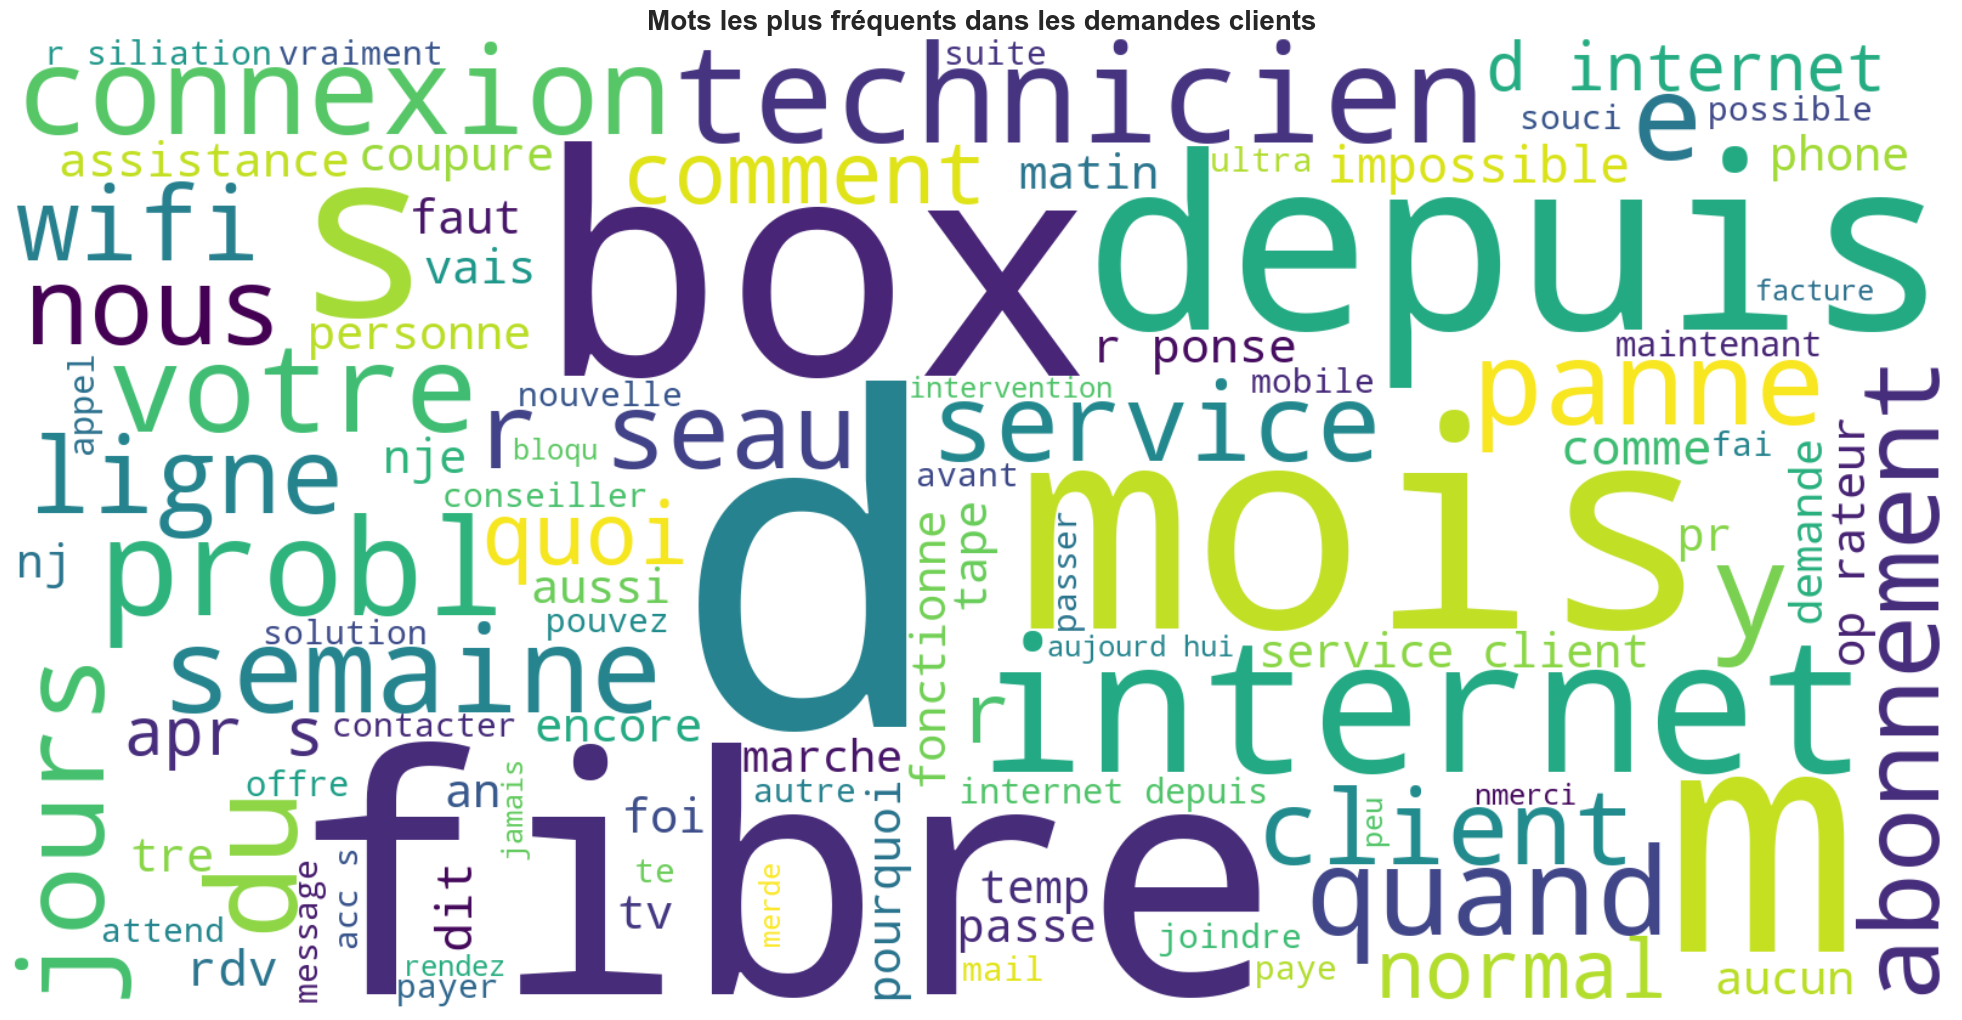

In [133]:
# Créer un word cloud des tweets pertinents (non-Freebox)
user_tweets = df_clean[df_clean['screen_name'] != 'Freebox']['clean_full_text']
all_text = ' '.join(user_tweets.dropna().astype(str))

# Mots à exclure
stopwords = {'free', 'freebox', 'https', 'co', 'rt', 'de', 'la', 'le', 'et', 'un', 'une', 
             'les', 'des', 'pour', 'pas', 'sur', 'est', 'que', 'qui', 'dans', 'avec', 'par',
             'en', 'vous', 'bonjour', "c\'est", 'mais', 'plus', 'ma', 'au', 'cette', 'ce', 'chez',
             'mon', 'me', 'toujours', 'je', 'merci', 'suis', 'car', 'rien', 'svp', 'meme', 'jour',
             'moi', 'j\'ai', 'sans', 'sont', 'ça', 'tout', 'tous', 'toute', 'toutes', 'on', 'alors','j', 'ai',
             'ne', 'tu', 'etre', 'ca', 'là', 'ou', 'à', 'avoir', 'il', 'non', 'ni', 'qu', 'n', 'a', 't', 'c',
             'ils', 'elle', 'elles', 'son', 'sa', 'ses', 'ceci', 'cela', 'celui', 'celle', 'dont',
             'où', 'faire', 'fait', 'été', 'être', 'suis', 'as', 'avons', 'avez', 'ont', 'étaient', 'était',
             'mes', 'tes', 'vos', 'notre', 'nos', 'leur', 'leurs', 'etes', 'étais', 'étais', 'étions', 'étiez',
             'donc', 'bien', 'peut', 'peux', 'veux', 'vouloir', 'si', 'se', 'lui', 'leur', 'leurs',
             'nou', 'dire', 'bon', 'vas', 'va', 'l', 'Free_1337', 'GroupeIliad', 'FreeMobile', 'free_mobile',
             'UniversFreebox', 'OQEEbyFree'


            }

# Générer le word cloud
wordcloud = WordCloud(width=1600, height=800, 
                      background_color='white',
                      stopwords=stopwords,
                      max_words=100,
                      colormap='viridis').generate(all_text)

# Afficher
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Mots les plus fréquents dans les demandes clients', fontsize=20, fontweight='bold')
plt.tight_layout(pad=0)
plt.show()

## 12. Recommandations et règles de filtrage

In [71]:
# Définir les règles de filtrage
filtrage_rules = [
    {
        "Priorité": "🔴 CRITIQUE",
        "Filtre": "Messages automatiques Freebox",
        "Regex": r"messagerie privée X n'est plus disponible|retrouvez-moi.*Messenger",
        "Impact": "~50% du volume",
        "Code": "df[~df['full_text'].str.contains('messagerie privée X', case=False, na=False)]"
    },
    {
        "Priorité": "🟠 HAUTE",
        "Filtre": "Retweets",
        "Regex": r"^RT @",
        "Impact": "Contenus non originaux",
        "Code": "df[~df['full_text'].str.startswith('RT @', na=False)]"
    },
    {
        "Priorité": "🟡 MOYENNE",
        "Filtre": "Messages trop courts",
        "Condition": "len(text) < 30",
        "Impact": "Messages non substantiels",
        "Code": "df[df['full_text'].str.len() >= 30]"
    },
    {
        "Priorité": "🟢 BASSE",
        "Filtre": "Spam/Promotion",
        "Liste noire": ["💩", "@fingapp", "@outagedetect"],
        "Impact": "Amélioration qualité",
        "Code": "df[~df['full_text'].str.contains('💩|@fingapp|@outagedetect', na=False)]"
    }
]

print("🛠️ RÈGLES DE FILTRAGE RECOMMANDÉES")
print("=" * 80)
print()

for rule in filtrage_rules:
    print(f"{rule['Priorité']} {rule['Filtre']}")
    print(f"   Impact attendu: Suppression de {rule['Impact']}")
    if 'Regex' in rule:
        print(f"   Pattern regex: {rule['Regex']}")
    elif 'Condition' in rule:
        print(f"   Condition: {rule['Condition']}")
    elif 'Liste noire' in rule:
        print(f"   Mots-clés à filtrer: {', '.join(rule['Liste noire'])}")
    print(f"   Code Python: {rule['Code']}")
    print()

# Fonction de filtrage complète
print("\n" + "=" * 80)
print("📝 FONCTION DE FILTRAGE COMPLÈTE")
print("=" * 80)
print()
print("""def clean_tweet_dataset(df):
    \"\"\"
    Nettoie le dataset de tweets en supprimant les tweets non pertinents.
    \"\"\"
    # Copie du DataFrame
    df_clean = df.copy()
    
    # Filtre 1: Supprimer les messages automatiques
    df_clean = df_clean[~df_clean['full_text'].str.contains(
        'messagerie privée X n\'est plus disponible', case=False, na=False)]
    
    # Filtre 2: Supprimer les retweets
    df_clean = df_clean[~df_clean['full_text'].str.startswith('RT @', na=False)]
    
    # Filtre 3: Supprimer les messages trop courts
    df_clean = df_clean[df_clean['full_text'].str.len() >= 30]
    
    # Filtre 4: Supprimer le spam
    spam_patterns = '💩|@fingapp|@outagedetect|via @fingapp'
    df_clean = df_clean[~df_clean['full_text'].str.contains(spam_patterns, na=False)]
    
    return df_clean
""")

🛠️ RÈGLES DE FILTRAGE RECOMMANDÉES

🔴 CRITIQUE Messages automatiques Freebox
   Impact attendu: Suppression de ~50% du volume
   Pattern regex: messagerie privée X n'est plus disponible|retrouvez-moi.*Messenger
   Code Python: df[~df['full_text'].str.contains('messagerie privée X', case=False, na=False)]

🟠 HAUTE Retweets
   Impact attendu: Suppression de Contenus non originaux
   Pattern regex: ^RT @
   Code Python: df[~df['full_text'].str.startswith('RT @', na=False)]

🟡 MOYENNE Messages trop courts
   Impact attendu: Suppression de Messages non substantiels
   Condition: len(text) < 30
   Code Python: df[df['full_text'].str.len() >= 30]

🟢 BASSE Spam/Promotion
   Impact attendu: Suppression de Amélioration qualité
   Mots-clés à filtrer: 💩, @fingapp, @outagedetect
   Code Python: df[~df['full_text'].str.contains('💩|@fingapp|@outagedetect', na=False)]


📝 FONCTION DE FILTRAGE COMPLÈTE

def clean_tweet_dataset(df):
    """
    Nettoie le dataset de tweets en supprimant les tweets non 

## 13. Métriques de performance et ROI

📈 MÉTRIQUES DE PERFORMANCE
Volume initial                 6375
Volume après nettoyage         3065
Tweets supprimés               3310
Taux de réduction              51.9%
Temps de traitement économisé  1655 minutes
Efficacité du filtrage         51.9%


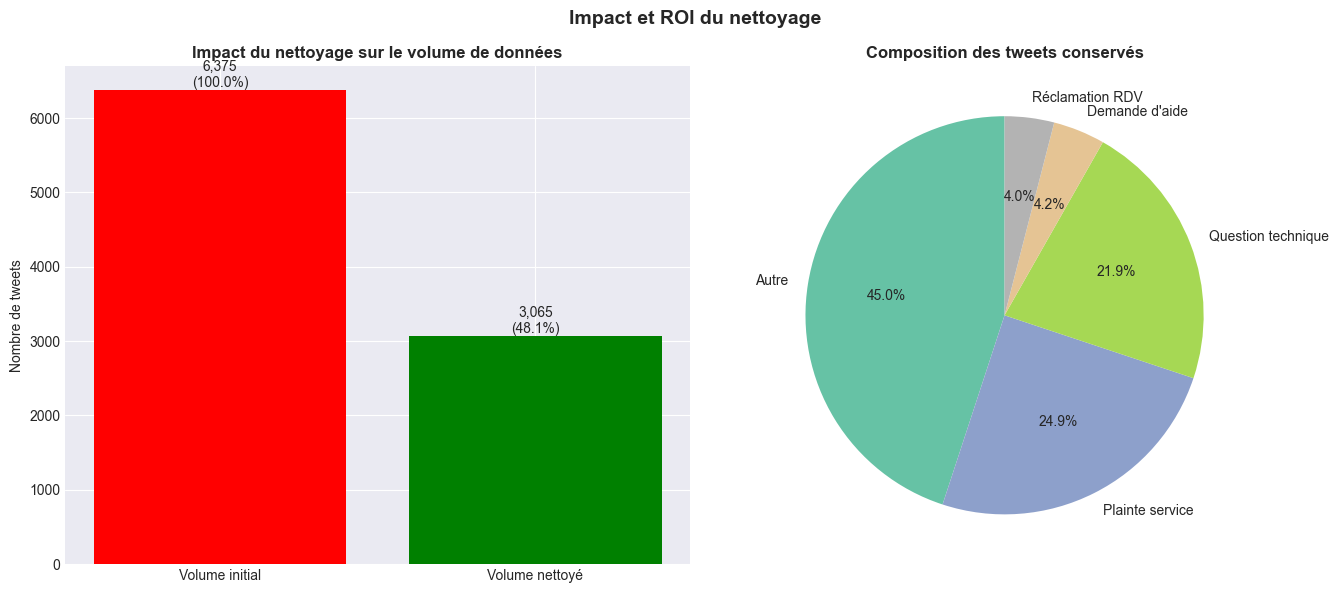

In [72]:
# Calculer les métriques de performance
metrics = {
    'Volume initial': len(df),
    'Volume après nettoyage': len(df_final),
    'Tweets supprimés': len(df) - len(df_final),
    'Taux de réduction': f"{(1 - len(df_final)/len(df))*100:.1f}%",
    'Temps de traitement économisé': f"{(len(df) - len(df_final))*0.5:.0f} minutes",  # Estimation: 30s par tweet
    'Efficacité du filtrage': f"{len(df_problematic)/len(df)*100:.1f}%"
}

print("📈 MÉTRIQUES DE PERFORMANCE")
print("=" * 60)
for key, value in metrics.items():
    print(f"{key:30} {value}")

# Visualisation du ROI
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Comparaison avant/après
categories = ['Volume initial', 'Volume nettoyé']
values = [len(df), len(df_final)]
bars = ax1.bar(categories, values, color=['red', 'green'])
ax1.set_ylabel('Nombre de tweets')
ax1.set_title('Impact du nettoyage sur le volume de données', fontweight='bold')

# Ajouter les valeurs
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:,}\n({value/len(df)*100:.1f}%)',
            ha='center', va='bottom')

# Répartition des tweets conservés
conserves_stats = df_final['categorie'].value_counts()
colors_conserves = plt.cm.Set2(np.linspace(0, 1, len(conserves_stats)))
ax2.pie(conserves_stats.values, labels=conserves_stats.index, autopct='%1.1f%%',
        colors=colors_conserves, startangle=90)
ax2.set_title('Composition des tweets conservés', fontweight='bold')

plt.suptitle('Impact et ROI du nettoyage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Export des résultats

In [73]:
# Sauvegarder les résultats
output_dir = 'C:/Users/AyoubJELLOULI/Desktop/HETIC/Projet_RNCP/git_repos/SAVAI-BACK/data/output/'  

# Créer le dossier s'il n'existe pas
import os
os.makedirs(output_dir, exist_ok=True)

# 1. Dataset nettoyé
df_final.to_csv(f'{output_dir}tweets_free_cleaned.csv', index=False)
print(f"✅ Dataset nettoyé sauvegardé: {output_dir}tweets_free_cleaned.csv")

# 2. Liste des tweets problématiques
df_problematic.to_csv(f'{output_dir}tweets_problematiques.csv', index=False)
print(f"✅ Tweets problématiques sauvegardés: {output_dir}tweets_problematiques.csv")

# 3. Statistiques générales
with open(f'{output_dir}statistiques_analyse.txt', 'w', encoding='utf-8') as f:
    f.write("STATISTIQUES D'ANALYSE DES TWEETS FREE\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Date d'analyse: {datetime.now().strftime('%d/%m/%Y %H:%M')}\n")
    f.write(f"Volume initial: {len(df):,} tweets\n")
    f.write(f"Volume après nettoyage: {len(df_final):,} tweets\n")
    f.write(f"Taux de réduction: {(1 - len(df_final)/len(df))*100:.1f}%\n\n")
    
    f.write("Répartition des catégories (après nettoyage):\n")
    for cat, count in df_final['categorie'].value_counts().items():
        f.write(f"  - {cat}: {count} ({count*100/len(df_final):.1f}%)\n")

print(f"✅ Statistiques sauvegardées: {output_dir}statistiques_analyse.txt")

print("\n" + "=" * 60)
print("🎉 ANALYSE TERMINÉE AVEC SUCCÈS !")
print("=" * 60)
print(f"\n📊 Résumé final:")
print(f"  • {len(df):,} tweets analysés")
print(f"  • {len(df_problematic):,} tweets problématiques identifiés ({len(df_problematic)*100/len(df):.1f}%)")
print(f"  • {len(df_final):,} tweets pertinents conservés ({len(df_final)*100/len(df):.1f}%)")
print(f"\n💡 Recommandation principale:")
print(f"  Implémenter le filtrage automatique des messages Freebox")
print(f"  pour réduire instantanément le volume de 50%")

PermissionError: [Errno 13] Permission denied: 'C:/Users/AyoubJELLOULI/Desktop/HETIC/Projet_RNCP/git_repos/SAVAI-BACK/data/output/tweets_free_cleaned.csv'

## Netoyage de la colonne full_text